# CMS Provider Fraud Models with SMOTE

Use the provider-level files from the original EDA notebook in `data/processed/`.

Keep the original workflow and compare five models:
- Logistic Regression
- Random Forest
- XGBoost
- KNN
- SVM

Load data → split → scale → SMOTE on training data → train models → compare validation results.

The validation set keeps its original class distribution. The same validation set is used to compare and select models, so these are validation results, not an independent final test estimate.

## 1. Import libraries

In [ ]:
# %pip install -q pandas numpy matplotlib scikit-learn xgboost imbalanced-learn joblib

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

RANDOM_STATE = 42

## 2. Load the EDA output files

In [2]:
from pathlib import Path

def find_project_root():
    """Find the project root from the notebook location."""
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/mnt/data/CMS_Fraud_Project_Complete_Final"),
    ]

    for candidate in candidates:
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Run the EDA notebook first."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

train_df = pd.read_csv(
    PROCESSED_DATA_DIR / "train_provider_features.csv"
)
test_df = pd.read_csv(
    PROCESSED_DATA_DIR / "test_provider_features.csv"
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (5410, 36)
Test shape: (1353, 34)
Out[0]: 
   Provider PotentialFraud  ...  ProcedureDiversityRatio  FraudLabel
0  PRV51001             No  ...                 0.080000           0
1  PRV51003            Yes  ...                 0.242424           1
2  PRV51004             No  ...                 0.000000           0
3  PRV51005            Yes  ...                 0.000000           1
4  PRV51007             No  ...                 0.013889           0

[5 rows x 36 columns]


## 3. Prepare features and target

In [3]:
# Create the binary fraud target.
if "FraudLabel" in train_df.columns:
    y = pd.to_numeric(
        train_df["FraudLabel"],
        errors="coerce",
    )
else:
    y = train_df["PotentialFraud"].map(
        {"No": 0, "Yes": 1}
    )

# Remove IDs and target columns.
drop_columns = [
    "Provider",
    "PotentialFraud",
    "FraudLabel",
]

X = train_df.drop(
    columns=drop_columns,
    errors="ignore",
)

X_test = test_df.drop(
    columns=drop_columns,
    errors="ignore",
)

# Convert features to numeric.
X = X.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

# Replace missing and infinite values.
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# Align test columns with training columns.
X_test = X_test.reindex(
    columns=X.columns,
    fill_value=0,
)

print("Number of features:", X.shape[1])
print("Fraud rate:", f"{y.mean():.2%}")

Number of features: 33
Fraud rate: 9.35%


## 4. Split training and validation data

In [4]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))

Training rows: 4057
Validation rows: 1353


## 5. Scale features and apply SMOTE

Fit the scaler on training data only. Apply SMOTE only to the scaled training data; do not resample validation data. All five models use the same balanced training data.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
FraudLabel
0    3678
1     379
Name: count, dtype: int64
After SMOTE:
FraudLabel
0    3678
1    3678
Name: count, dtype: int64


## 6. Train Logistic Regression

In [6]:
# SMOTE already balances the classes, so class_weight is not needed.
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
)
logistic_model.fit(X_train_smote, y_train_smote)
logistic_probability = logistic_model.predict_proba(X_valid_scaled)[:, 1]

## 7. Train Random Forest

In [7]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
random_forest_model.fit(X_train_smote, y_train_smote)
random_forest_probability = random_forest_model.predict_proba(X_valid_scaled)[:, 1]

## 8. Train XGBoost

In [8]:
# Do not also add scale_pos_weight after balancing with SMOTE.
xgboost_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
xgboost_model.fit(X_train_smote, y_train_smote)
xgboost_probability = xgboost_model.predict_proba(X_valid_scaled)[:, 1]

## 9. Train KNN

In [9]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_smote, y_train_smote)
knn_probability = knn_model.predict_proba(X_valid_scaled)[:, 1]

## 10. Train SVM

In [10]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=RANDOM_STATE,
)
svm_model.fit(X_train_smote, y_train_smote)
svm_probability = svm_model.predict_proba(X_valid_scaled)[:, 1]

## 11. Compare all five models

Use the same validation data and a 0.5 threshold for every model. Average precision (AP) is the ranking metric; it is not accuracy or trapezoidal PR area. Precision, recall and F1 below describe the positive class. Scores after SMOTE should not be interpreted as calibrated real-world fraud probabilities.

In [11]:
probabilities = {
    "Logistic Regression": logistic_probability,
    "Random Forest": random_forest_probability,
    "XGBoost": xgboost_probability,
    "KNN": knn_probability,
    "SVM": svm_probability,
}

results = []
for name, probability in probabilities.items():
    prediction = (probability >= 0.50).astype(int)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, prediction),
        "Precision": precision_score(y_valid, prediction, zero_division=0),
        "Recall": recall_score(y_valid, prediction, zero_division=0),
        "F1": f1_score(y_valid, prediction, zero_division=0),
        "Average_Precision": average_precision_score(y_valid, probability),
        "ROC_AUC": roc_auc_score(y_valid, probability),
    })

results_df = pd.DataFrame(results).sort_values(
    "Average_Precision", ascending=False
).reset_index(drop=True)
results_df.round(4)

Out[0]: 
                 Model  Accuracy  Precision  ...      F1  Average_Precision  ROC_AUC
0  Logistic Regression    0.9039     0.4933  ...  0.6286             0.7580   0.9585
1              XGBoost    0.9335     0.6164  ...  0.6853             0.7439   0.9571
2        Random Forest    0.9290     0.5917  ...  0.6757             0.7007   0.9569
3                  SVM    0.9076     0.5046  ...  0.6377             0.6027   0.9442
4                  KNN    0.8736     0.4167  ...  0.5627             0.4948   0.9198

[5 rows x 7 columns]


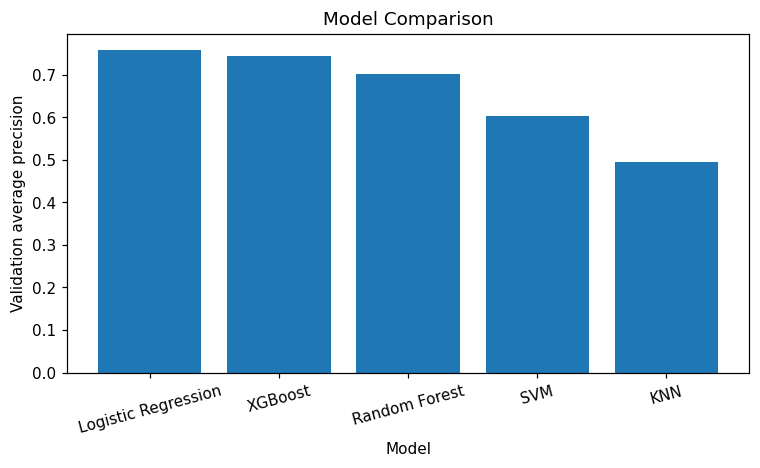

In [12]:
plt.figure(figsize=(8, 4))

plt.bar(
    results_df["Model"],
    results_df["Average_Precision"],
)

plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Validation average precision")
plt.xticks(rotation=15)
plt.show()

## 12. Evaluate the best validation model

In [13]:
best_model_name = results_df.loc[0, "Model"]
best_probability = probabilities[best_model_name]

best_prediction = (
    best_probability >= 0.50
).astype(int)

print("Best model:", best_model_name)
print()
print(
    classification_report(
        y_valid,
        best_prediction,
        target_names=["Non-Fraud", "Fraud"],
        digits=4,
    )
)

Best model: Logistic Regression

              precision    recall  f1-score   support

   Non-Fraud     0.9850    0.9078    0.9448      1226
       Fraud     0.4933    0.8661    0.6286       127

    accuracy                         0.9039      1353
   macro avg     0.7391    0.8870    0.7867      1353
weighted avg     0.9388    0.9039    0.9151      1353



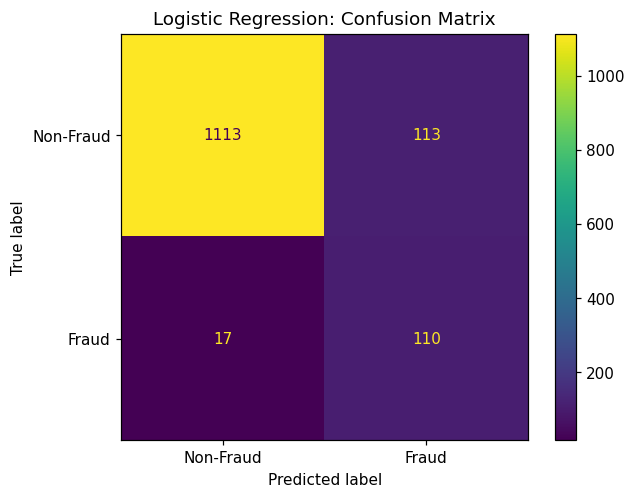

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    best_prediction,
    display_labels=["Non-Fraud", "Fraud"],
)

plt.title(f"{best_model_name}: Confusion Matrix")
plt.show()

## 13. Show feature importance

Logistic Regression and tree models provide coefficients or built-in feature importance. KNN and RBF SVM do not, so skip this step if either is selected.

In [15]:
feature_importance = pd.DataFrame(columns=["Feature", "Importance"])

if best_model_name == "Logistic Regression":
    importance = np.abs(logistic_model.coef_[0])
elif best_model_name == "Random Forest":
    importance = random_forest_model.feature_importances_
elif best_model_name == "XGBoost":
    importance = xgboost_model.feature_importances_
else:
    importance = None
    print("KNN and RBF SVM do not have built-in feature importance.")

if importance is not None:
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance,
    }).sort_values("Importance", ascending=False)

feature_importance.head(15)

Out[0]: 
                        Feature  Importance
14              HospitalStayMax    1.702297
0                    ClaimCount    1.690427
4           ReimbursementMedian    1.447198
1           UniqueBeneficiaries    1.183509
13             HospitalStayMean    1.121131
2            ReimbursementTotal    0.891622
27  ReimbursementPerBeneficiary    0.834907
8                DeductibleMean    0.698731
3             ReimbursementMean    0.571912
28        ReimbursementPerClaim    0.571912
15           DiagnosisCountMean    0.557798
5              ReimbursementStd    0.493224
10          InpatientClaimCount    0.463780
25      UniquePrimaryProcedures    0.463745
9                 DeductibleMax    0.456943


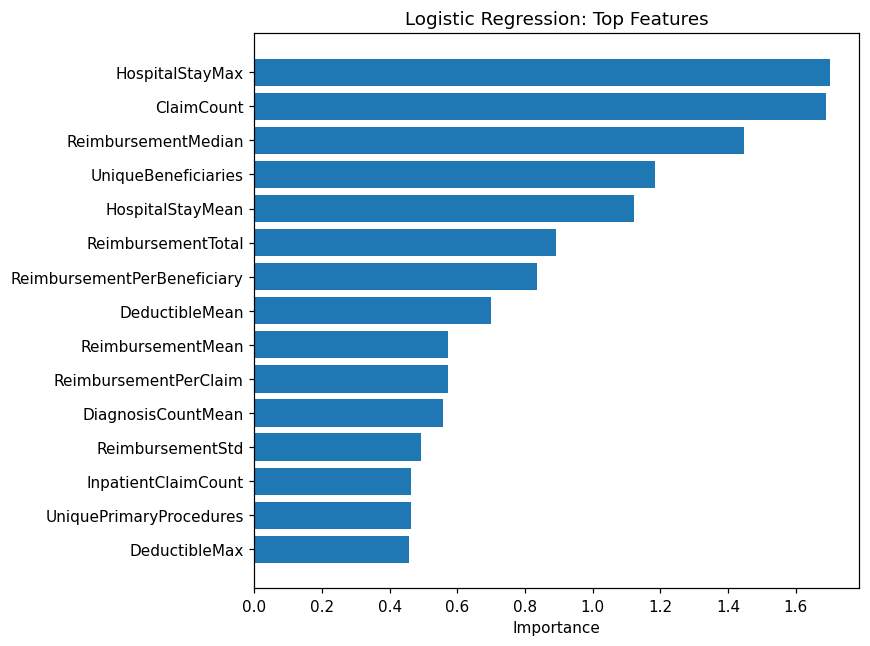

In [16]:
if not feature_importance.empty:
    top_features = feature_importance.head(15).sort_values("Importance")
    plt.figure(figsize=(8, 6))
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.title(f"{best_model_name}: Top Features")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

## 14. Save the comparison table

In [17]:
report_folder = PROJECT_ROOT / "artifacts" / "reports"
report_folder.mkdir(parents=True, exist_ok=True)
results_df.to_csv(report_folder / "smote_model_comparison.csv", index=False)
print("Saved: artifacts/reports/smote_model_comparison.csv")

Saved: artifacts/reports/smote_model_comparison.csv


## Conclusion

All five models use the same SMOTE-balanced training data. Compare accuracy together with precision, recall, F1 and average precision. These are provider-level screening labels, not proof of fraud.



Five models are trained on SMOTE-balanced provider data and evaluated using accuracy, precision, recall, F1, 
and average precision. SMOTE is applied only to the training set. 
The best model is logistic regression.

Note: Data from Kaggle.